# Multimodal RAG with Milvus
本教程展示了由Milvus、可视化BGE模型和DS共同驱动的多模态RAG系统。该系统支持用户上传图片并编辑文本指令，BGE的复合检索模型将处理这些指令以搜索候选图片，随后DS作为重排序模块，选出最合适的图片，并说明选择依据。这一强大组合实现了无缝且直观的图像搜索体验，充分利用Milvus实现高效检索，BGE模型进行精准的图像处理与匹配，以及DS提供高级重排序功能。
<img src="multimodal_rag_with_milvus.png">
## 下载数据
以下命令将下载示例数据，并提取到本地文件夹 "./images_folder" 中，内容包括：
- images：来自 Amazon 2023 年评论数据的一个子集，包含约 900 张图片，类别为“家电”、“手机及配件”和“电子产品”。
- leopard.jpg：一个示例查询图像。

In [1]:
#!curl -O https://github.com/milvus-io/bootcamp/releases/download/data/amazon_reviews_2023_subset.tar.gz

In [2]:
import os

os.environ['NLTK_DATA'] = r'F:\Teewon\Milvue\model\nltk_data'

CUSTOM_CACHE = r'F:\Teewon\Milvue\models'
os.environ['HF_HOME'] = CUSTOM_CACHE
os.environ['HF_HUB_CACHE'] = os.path.join(CUSTOM_CACHE, 'hub')
os.environ['TORCH_HOME'] = CUSTOM_CACHE

In [3]:
import dotenv

dotenv.load_dotenv('../.env')

True

## 加载嵌入模型
我们将使用可视化BGE模型“bge-visualized-base-en-v1.5”为图像和文本生成嵌入。

**1. Build encoder**

In [ ]:
#!wget https://huggingface.co/BAAI/bge-visualized/resolve/main/Visualized_base_en_v1.5.pth

**2. Build encoder**

In [11]:
import torch
import sys
from typing import List
sys.path.append(r'F:\Teewon\FlagEmbedding\research\visual_bge')
from visual_bge.modeling import Visualized_BGE

class Encoder:
    def __init__(self,model_name:str,model_path:str):
        self.model = Visualized_BGE(model_name_bge=model_name,model_weight=model_path)
        self.model.eval()

    def encoder_query(self,image_path:str,text:str)->List[float]:
        with torch.no_grad():
            query_emb=self.model.encode(image=image_path,text=text)
        return query_emb.tolist()[0]

    def encoder_image(self,image_path:str)->List[float]:
        with torch.no_grad():
            query_emb=self.model.encode(image=image_path)
        return query_emb.tolist()[0]

model_name="BAAI/bge-base-en-v1.5"
model_path="../models/BGE-visualized/Visualized_base_en_v1.5.pth"
encoder=Encoder(model_name,model_path)

## 加载数据
本部分将把示例图像及其对应的嵌入向量加载到数据库中。

### 生成嵌入向量
从数据目录加载所有JPEG图像，并使用编码器将图像转换为嵌入向量。

In [12]:
from tqdm import tqdm
from glob import glob
import traceback

data_dir="./data/images_folder"
image_list=glob(os.path.join(data_dir,'images',"*.jpg"))

image_dict={}
for img_path in tqdm(image_list,desc="Generating image embeddings: "):
    try:
        image_dict[img_path]=encoder.encoder_image(img_path)
    except Exception as e:
        print(f"Failed to generate embedding for {img_path}. Skipped.")
        traceback.print_exc()
        continue
print("Number of encoded images:", len(image_dict))

Generating image embeddings: 100%|██████████| 900/900 [00:30<00:00, 29.97it/s]

Number of encoded images: 900


### 插入到 Milvus
将包含对应路径和嵌入的图像插入Milvus集合。

In [13]:
dim=len(list(image_dict.values())[0])

from pymilvus import MilvusClient

mc=MilvusClient(uri="http://localhost:19530")
collection_name = "multimodal_rag_demo"

mc.create_collection(
    collection_name,
    auto_id=True,
    dimension=dim,
    enable_dynamic_field=True,
    overwrite=True,
)

mc.insert(
    collection_name,
    data=[{"image_path":k,"vector":v}for k,v in image_dict.items()],
)

{'insert_count': 900, 'ids': [468817559495909273, 468817559495909274, 468817559495909275, 468817559495909276, 468817559495909277, 468817559495909278, 468817559495909279, 468817559495909280, 468817559495909281, 468817559495909282, 468817559495909283, 468817559495909284, 468817559495909285, 468817559495909286, 468817559495909287, 468817559495909288, 468817559495909289, 468817559495909290, 468817559495909291, 468817559495909292, 468817559495909293, 468817559495909294, 468817559495909295, 468817559495909296, 468817559495909297, 468817559495909298, 468817559495909299, 468817559495909300, 468817559495909301, 468817559495909302, 468817559495909303, 468817559495909304, 468817559495909305, 468817559495909306, 468817559495909307, 468817559495909308, 468817559495909309, 468817559495909310, 468817559495909311, 468817559495909312, 468817559495909313, 468817559495909314, 468817559495909315, 468817559495909316, 468817559495909317, 468817559495909318, 468817559495909319, 468817559495909320, 4688175594

## 多模态搜索结合生成式重排序
在本节中，我们首先通过多模态查询搜索相关图像，然后利用LLM服务对结果进行重排序，找出最佳结果并附上解释。
### 运行搜索
现在我们可以使用包含图像和文本指令的查询数据，执行高级图像搜索。

In [14]:
query_image=os.path.join(data_dir,"leopard.jpg")
query_text="phone case with this image theme"

query_vec=encoder.encoder_query(image_path=query_image,text=query_text)

search_results=mc.search(
    collection_name,
    data=[query_vec],
    output_fields=["image_path"],
    limit=9,
    search_params={"metric_type":"COSINE","params":{}}
)[0]

retrieved_images=[hit['entity']['image_path'] for hit in search_results]
print(retrieved_images)

['./data/images_folder\\images\\518Gj1WQ-RL._AC_.jpg', './data/images_folder\\images\\41n00AOfWhL._AC_.jpg', './data/images_folder\\images\\51Wqge9HySL._AC_.jpg', './data/images_folder\\images\\51R2SZiywnL._AC_.jpg', './data/images_folder\\images\\516PebbMAcL._AC_.jpg', './data/images_folder\\images\\51RrgfYKUfL._AC_.jpg', './data/images_folder\\images\\515DzQVKKwL._AC_.jpg', './data/images_folder\\images\\51BsgVw6RhL._AC_.jpg', './data/images_folder\\images\\51INtcXu9FL._AC_.jpg']


### 使用DS重新排序
我们将利用大语言模型对图像进行排序，并根据用户查询和检索结果生成最佳结果的解释。

**1. 创建全景视图**

In [25]:
import numpy as np
import cv2
from PIL import Image

img_height=300
img_width=300
row_count=3

def create_panoramic_view(query_image_path:str,retrieved_images:list)->np.ndarray:
    """
    creates a 5x5 panoramic view image from a list of images

    args:
        images: list of images to be combined

    returns:
        np.ndarray: the panoramic view image
    """
    panoramic_width=img_width*row_count
    panoramic_height=img_height*row_count
    panoramic_image=np.full(
        (panoramic_height,panoramic_width,3),225,dtype=np.uint8
    )

    # 创建并调整查询图像的大小，添加蓝色边框
    query_image_null=np.full((panoramic_height,img_width,3),255,dtype=np.uint8)
    query_image=Image.open(query_image_path).convert("RGB")
    query_array=np.array(query_image)[:,:,::-1]
    resized_image=cv2.resize(query_array,(img_height,img_width))

    border_size=10
    blue=(255,0,0)
    bordered_query_image=cv2.copyMakeBorder(
        resized_image,
        border_size,
        border_size,
        border_size,
        border_size,
        cv2.BORDER_CONSTANT,
        value=blue,
    )
    query_image_null[img_height*2:img_height*3,0:img_width]=cv2.resize(bordered_query_image,(img_width,img_height))

    # 在查询图片下方添加“query”文本
    text='query'
    font_scale=1
    font_thickness=2
    text_org=(10,img_height*10+30)
    cv2.putText(
        query_image_null,
        text,
        text_org,
        cv2.FONT_HERSHEY_SIMPLEX,
        font_scale,
        blue,
        font_thickness,
        cv2.LINE_AA,
    )

    # combine the rest of the images into the panoramic view
    retrieved_imgs=[
        np.array(Image.open(img).convert("RGB"))[:,:,::-1] for img in retrieved_images
    ]
    for i,image in enumerate(retrieved_imgs):
        image=cv2.resize(image,(img_width-4,img_height-4))
        row=i//row_count
        col=i%row_count
        start_row=row*img_height
        start_col=col*img_width

        border_size=2
        bordered_image=cv2.copyMakeBorder(
            image,
            border_size,
            border_size,
            border_size,
            border_size,
            cv2.BORDER_CONSTANT,
            value=(0,0,0),
        )
        panoramic_image[
            start_row:start_row+img_height,start_col:start_col+img_width,
        ]=bordered_image

        # add red index numbers to each image
        text=str(i)
        org=(start_col+50,start_row+30)
        (font_width,font_height),baseline=cv2.getTextSize(text,cv2.FONT_HERSHEY_SIMPLEX,1,2)

        top_left=(org[0]-48,start_row+2)
        bottom_right=(org[0]-48+font_width+5,org[1]+baseline+5)

        cv2.rectangle(
            panoramic_image,
            top_left,
            bottom_right,
            (255,255,255),
            cv2.FILLED,
        )
        cv2.putText(
            panoramic_image,
            text,
            (start_col+10,start_row+30),
            cv2.FONT_HERSHEY_SIMPLEX,
            1,
            (0,0,255),
            2,
            cv2.LINE_AA,
        )

    # combine the query image with the panoramic view
    panoramic_image=np.hstack([query_image_null,panoramic_image])
    return panoramic_image

Combine the query image and retrieved images with indices in a panoramic view.

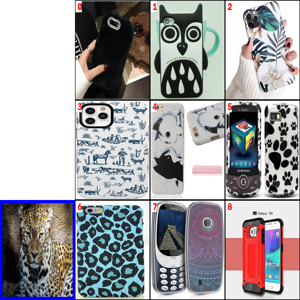

In [40]:
combined_image_path=os.path.join(data_dir,"combined_image.png")
panoramic_image=create_panoramic_view(query_image,retrieved_images)
cv2.imwrite(combined_image_path,panoramic_image)

combined_image=Image.open(combined_image_path)
#show_combined_image=combined_image.resize((300,300))
show_combined_image

**2. 重新排序并解释**

我们将把合成的图像连同适当的提示一起发送给多模态大语言模型服务，以对检索结果进行排序并附上解释。若要使用DS作为大语言模型，您需要准备您的DS API密钥。

In [41]:
import requests
import base64

api_key=os.getenv("DEEPSEEK_API_KEY")

In [42]:
import re

# 从响应中解析排名索引（正则，容错格式）
def parse_ranking(content):
    # 找所有方括号/圆括号里的整数序列
    m = re.search(r'\[([\d\s,]+)\]', content)
    if not m:
        m = re.search(r'\(([\d\s,]+)\)', content)
    if m:
        ranked_indices = [int(x) for x in re.findall(r'\d+', m.group(1))]
    else:
        # 退路：全文找所有数字
        ranked_indices = [int(x) for x in re.findall(r'\b\d+\b', content)]
    # 去掉可能的解释数字干扰：只保留 0-8 范围内的
    ranked_indices = [i for i in ranked_indices if 0 <= i <= 8]
    # 取 "Reasons" 之后作为解释
    if 'Reasons' in content:
        explanation = content.split('Reasons', 1)[1].lstrip(' :')
    else:
        explanation = content
    return ranked_indices, explanation

In [43]:
def generate_ranking_explanation(combined_image_path,caption,infos:dict=None)->tuple[list[int],str]:
    with open(combined_image_path,'rb') as img_f:
        base64_image=base64.b64encode(img_f.read()).decode("utf-8")
    infomation=(
        "You are responsible for ranking results for a Composed Image Retrieval. "
        "The user retrieves an image with an 'instruction' indicating their retrieval intent. "
        "For example, if the user queries a red car with the instruction 'change this car to blue,' a similar type of car in blue would be ranked higher in the results. "
        "Now you would receive instruction and query image with blue border. Every item has its red index number in its top left. Do not misunderstand it. "
        f"User instruction: {caption} \n\n"
    )

    # add additional information for each image
    if infos:
        for i,info in enumerate(infos["product"]):
            infomation+=f"{i}.{info}\n"

    infomation+=(
        "Provide a new ranked list of indices from most suitable to least suitable, followed by an explanation for the top 1 most suitable item only. "
        "The format of the response has to be 'Ranked list: []' with the indices in brackets as integers, followed by 'Reasons:' plus the explanation why this most fit user's query intent."
    )
    headers={
        "Content-Type": "application/json",
        "Authorization": f"Bearer {api_key}",
    }

    payload={
        "model":"deepseek-v4-flash-vision-exp",
        "messages":[
            {
                "role":"user",
                "content":[
                    {"type":"text","text":infomation},
                    {
                        "type":"image_url",
                        "image_url":{"url":f"data:image/jpeg;base64,{base64_image}"},
                    }
                ]
            }
        ],
        # "max_tokens":300,
    }

    # 使用的是 requests 库直接调用，所以需要指定完整的 API 路径，而不仅仅是 Base URL。如果你使用的是 OpenAI 官方 SDK，则只需设置 base_url="https://api.deepseek.com"。
    response=requests.post(
        "https://api.deepseek.com/v1/chat/completions",headers=headers,json=payload,
    )
    result=response.json()["choices"][0]["message"]["content"]

    # 从响应中解析排名索引
    if not result.strip():
        raise RuntimeError("Model returned empty response.")
    ranked_indices,explanation=parse_ranking(result)
    return ranked_indices, explanation

获取排序后的图像索引以及最佳结果的原因：

In [44]:
ranked_indices,explanation=generate_ranking_explanation(
    combined_image_path,query_text
)
print("ranked:", ranked_indices)
print("reason:", explanation)

ranked: [6, 5, 3, 4, 1, 0, 2, 7, 8]
reason: The most suitable item is index 6 because it features a leopard print pattern, which directly matches the theme of the leopard in the query image. The blue background of the case also aligns with the blue border of the query image.


**3. Display the best result with explanation**

The most suitable item is index 6 because it features a leopard print pattern, which directly matches the theme of the leopard in the query image. The blue background of the case also aligns with the blue border of the query image.


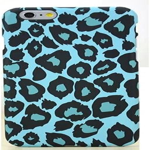

In [46]:
print(explanation)

best_index = ranked_indices[0]
best_img = Image.open(retrieved_images[best_index])
best_img = best_img.resize((150, 150))
best_img

In [47]:
mc.drop_collection(collection_name)